# 中国电商平台：用户分层可视化与业务画像

观察期：**2017-11-25 至 2017-12-03，Asia/Shanghai**。使用 `sql/06_user_segmentation.sql` 作为唯一分层规则来源，不在 Python 中重写 CASE 或分位阈值。本章是 **RF + 行为特征分析**，没有金额，不能推断收入贡献；buy 事件不是订单。

本 Notebook 保存了执行输出，GitHub 可直接阅读；重跑需要本地 `data/processed/ecommerce.duckdb`。从项目根目录或 notebooks 目录启动均可。Python 依赖：`duckdb pandas numpy matplotlib seaborn nbformat nbclient ipykernel`，可在项目虚拟环境中通过 `python -m pip install` 安装。中文字体推荐 Noto Sans CJK SC、微软雅黑或苹方；没有可用字体时会停止，避免生成乱码图。

执行流程：只读连接复现 SQL → 核对全部用户与分群 → 汇总绘图 → 业务解释。所有分群“未购买”“近期”“高频”均限定九天窗口。

In [1]:
from pathlib import Path
import hashlib
import tempfile
import platform
import sys
import duckdb
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, ticker
import seaborn as sns
from IPython.display import display, Markdown

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'sql/06_user_segmentation.sql').exists()), None)
if root is None:
    raise FileNotFoundError('请从项目根目录或 notebooks 目录启动。')
db_path = root / 'data/processed/ecommerce.duckdb'
sql_path = root / 'sql/06_user_segmentation.sql'
window_end = pd.Timestamp('2017-12-03')
print('Python:', sys.version.split()[0], '| DuckDB:', duckdb.__version__,
      '| pandas:', pd.__version__, '| matplotlib:', matplotlib.__version__)
print('SQL SHA256:', hashlib.sha256(sql_path.read_bytes()).hexdigest())

Python: 3.13.0 | DuckDB: 1.5.6 | pandas: 3.0.6 | matplotlib: 3.11.2
SQL SHA256: c89510b02a586f22e61dc51d1db4ab2cbd406a2892b04dc73c25aad4a30deb53


## 1. 复现 SQL 并校验数据

只读连接不改变数据库。执行原 SQL 的计算与校验语句，暂缓末尾 TEMP 清理，读取用户明细后再执行清理并关闭连接。字段只是别名映射：`buy_event_count → buy_events`、`buy_active_days → purchase_days`、`buy_distinct_items → purchased_items`、`buy_distinct_categories → purchased_categories`；`user_segment` 使用 SQL 中的中文名称。

下面的固定人数是已验证数据版本的核对基准，不参与分层。任何 SQL 检查、用户数或分群人数不一致都会抛出异常，后续图表不得继续生成。

In [2]:
expected_counts = {
    'active_frequent_buyer': 63055, 'frequent_buyer': 104932,
    'recent_buyer': 242300, 'purchase_cooling': 154066,
    'other_buyer': 108051, 'active_nonbuyer': 105478,
    'cart_nonbuyer': 129320, 'favorite_nonbuyer': 31746,
    'lower_activity_browser': 49043,
}
with tempfile.TemporaryDirectory(prefix='ecommerce-segmentation-') as spill_dir:
    con = duckdb.connect(str(db_path), read_only=True)
    try:
        con.execute("SET memory_limit='3GB'")
        con.execute('SET threads=4')
        con.execute("SET temp_directory = '" + spill_dir.replace("'", "''") + "'")
        cleanup, sql_checks = [], None
        for statement in con.extract_statements(sql_path.read_text()):
            if statement.type == duckdb.StatementType.DROP:
                cleanup.append(statement)
                continue
            result = con.execute(statement)
            if statement.type == duckdb.StatementType.SELECT:
                if result.description and result.description[0][0] == 'check_name':
                    sql_checks = result.fetchdf()
        if sql_checks is None or not sql_checks['invalid_rows'].eq(0).all():
            raise ValueError(f'SQL 一致性检查未通过：{sql_checks}')
        users = con.execute("""
            SELECT u.user_id, u.segment_code, c.segment_name AS user_segment,
                   u.active_days, u.pv_events, u.cart_events, u.fav_events,
                   u.buy_event_count AS buy_events, u.buy_active_days AS purchase_days,
                   u.buy_distinct_items AS purchased_items,
                   u.buy_distinct_categories AS purchased_categories,
                   u.recency_days, u.total_events, u.distinct_categories,
                   u.last_active_date, u.last_purchase_date, u.first_observed_active_date
            FROM segmentation_users u JOIN segmentation_catalog c USING(segment_code)
        """).fetchdf()
        sql_summary = con.execute('SELECT * FROM segmentation_summary ORDER BY sort_order').fetchdf()
        catalog = con.execute('SELECT * FROM segmentation_catalog ORDER BY sort_order').fetchdf()
        thresholds = con.execute('SELECT * FROM segmentation_thresholds').fetchdf()
        for statement in cleanup:
            con.execute(statement)
    finally:
        con.close()

counts = users.groupby('segment_code').size().to_dict()
assert len(users) == 987991, f'总用户数异常：{len(users)}'
assert users['user_id'].notna().all() and users['user_id'].is_unique, '用户归属不唯一'
assert users['user_segment'].notna().all()
assert int(users['buy_events'].gt(0).sum()) == 672404, '购买用户数异常'
assert int(users['purchase_days'].ge(2).sum()) == 370274, '跨日重复购买用户数异常'
assert counts == expected_counts, f'分群不一致：{counts}'
assert counts == sql_summary.set_index('segment_code')['users'].to_dict()
users['days_since_last_active'] = (window_end - users['last_active_date']).dt.days
buyers = users.loc[users['buy_events'].gt(0)].copy()
nonbuyers = users.loc[users['buy_events'].eq(0)].copy()
assert buyers['recency_days'].between(0, 8).all()
assert nonbuyers['recency_days'].isna().all()
display(sql_checks, thresholds)
print(f'验证通过：{len(users):,} 用户；{len(buyers):,} 购买用户；九个分群人数全部一致。')

,check_name,invalid_rows
0,duplicate_segment_users,0.0
1,missing_or_unknown_segment,0.0
2,segment_total_mismatch,0.0
3,invalid_recency,0.0
4,invalid_frequency,0.0
5,invalid_activity,0.0
6,reference_total_mismatch,0.0
7,purchasing_users_mismatch,0.0
8,repeat_purchase_users_mismatch,0.0


,all_active_days_q75,nonbuyer_active_days_q75,buyer_buy_days_q75,buyer_recency_median,buyer_recency_q75
0,9,8,3,2,4


验证通过：987,991 用户；672,404 购买用户；九个分群人数全部一致。


## 2. 绘图规范与群体汇总

图表统一使用中文、千位分隔和两位百分比。行为次数是九天累计值的用户等权平均；活跃天数与购买日期数均按不同自然日计算。Recency 表示距 12/03 最后购买日期的天数，不是两次购买间隔。

In [3]:
sns.set_theme(style='whitegrid', context='notebook')
font_paths = [Path('/System/Library/Fonts/PingFang.ttc'),
              Path('/System/Library/Fonts/Supplemental/Songti.ttc'),
              Path('C:/Windows/Fonts/msyh.ttc'),
              Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')]
font_names = ['Noto Sans CJK SC', 'Microsoft YaHei', 'PingFang SC', 'SimHei']
font_path = next((p for p in font_paths if p.exists()), None)
if font_path:
    font_manager.fontManager.addfont(str(font_path))
    font_name = font_manager.FontProperties(fname=str(font_path)).get_name()
else:
    font_name = next((name for name in font_names
                     if any(f.name == name for f in font_manager.fontManager.ttflist)), None)
if not font_name:
    raise RuntimeError('请安装 Noto Sans CJK SC 或配置可用中文字体后再绘图。')
plt.rcParams.update({'font.family': font_name, 'axes.unicode_minus': False,
                     'figure.dpi': 110, 'savefig.dpi': 180,
                     'axes.spines.top': False, 'axes.spines.right': False})
figure_dir = root / 'reports/figures'
figure_dir.mkdir(parents=True, exist_ok=True)
segment_names = catalog.set_index('segment_code')['segment_name'].to_dict()
segment_colors = dict(zip(catalog['segment_code'], sns.color_palette('colorblind', 9)))
metrics = ['active_days', 'pv_events', 'cart_events', 'fav_events', 'buy_events', 'purchase_days']
metric_names = {'active_days': '平均活跃天数', 'pv_events': '平均浏览次数',
                'cart_events': '平均加购次数', 'fav_events': '平均收藏次数',
                'buy_events': '平均购买事件数', 'purchase_days': '平均购买日期数'}
profile = users.groupby('segment_code')[metrics + ['purchased_categories', 'recency_days']].mean()
summary = profile.join(users.groupby('segment_code').size().rename('users'))
summary['share_pct'] = summary['users'] / len(users) * 100
summary = summary.sort_values('users', ascending=False)
# 核对 Python 汇总均值与原 SQL 汇总，允许 SQL 四位小数的舍入误差。
for python_name, sql_name in [('active_days', 'avg_active_days'), ('pv_events', 'avg_pv_events'),
                              ('cart_events', 'avg_cart_events'), ('fav_events', 'avg_fav_events'),
                              ('buy_events', 'avg_buy_event_count'), ('purchase_days', 'avg_buy_active_days')]:
    assert np.allclose(profile.loc[sql_summary['segment_code'], python_name],
                       sql_summary[sql_name].astype(float), atol=0.000051)
def save_chart(fig, filename):
    fig.savefig(figure_dir / filename, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
def bars(ax, labels, values, colors, title, xlabel, percent=False):
    ax.barh(labels, values, color=colors)
    ax.invert_yaxis()
    ax.set(title=title, xlabel=xlabel)
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(100, decimals=2) if percent else
                                ticker.StrMethodFormatter('{x:,.0f}'))
    max_value = max(values) if len(values) else 0
    ax.set_xlim(0, max_value * 1.25 if max_value > 0 else 1)
    for i, value in enumerate(values):
        ax.text(value + max_value * 0.02, i,
                f'{value:.2f}%' if percent else (f'{value:,.0f}' if xlabel == '人' else f'{value:,.2f}'), va='center', fontsize=9)
display(summary.rename(index=segment_names).rename(columns=metric_names).round(2))

,平均活跃天数,平均浏览次数,平均加购次数,平均收藏次数,平均购买事件数,平均购买日期数,purchased_categories,recency_days,users,share_pct
segment_code,,,,,,,,,,
近期购买用户,6.76,85.57,5.48,2.69,2.16,1.51,1.94,0.84,242300,24.52
购买沉寂观察用户,7.42,96.84,5.81,3.07,1.82,1.27,1.64,6.28,154066,15.59
加购未购买用户,5.65,55.24,4.85,1.52,0.00,0.00,0.00,<NA>,129320,13.09
其他已购买用户,7.36,96.96,5.96,2.99,2.02,1.41,1.82,3.48,108051,10.94
高活跃未购买用户,8.48,118.25,5.76,4.04,0.00,0.00,0.00,<NA>,105478,10.68
高频重复购买用户,7.32,98.15,6.97,3.04,5.43,3.49,4.63,1.21,104932,10.62
高活跃高频购买用户,9.00,164.44,11.06,5.26,6.74,4.07,5.68,0.71,63055,6.38
相对低活跃仅浏览用户,5.20,32.04,0.00,0.00,0.00,0.00,0.00,<NA>,49043,4.96
收藏未购买用户,5.60,52.77,0.00,5.25,0.00,0.00,0.00,<NA>,31746,3.21


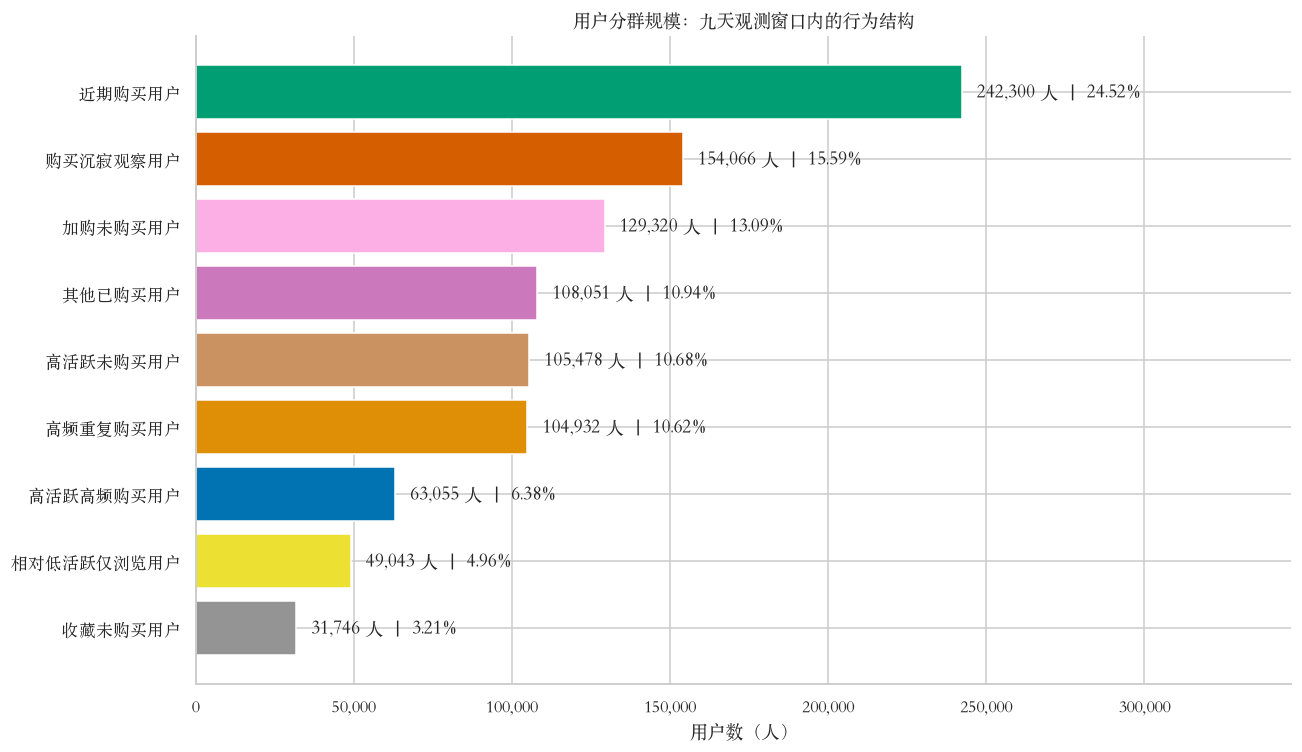

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
order = summary.index.tolist()
values = summary['users'].to_numpy()
ax.barh([segment_names[x] for x in order], values, color=[segment_colors[x] for x in order])
ax.invert_yaxis()
ax.set(title='用户分群规模：九天观测窗口内的行为结构', xlabel='用户数（人）')
ax.set_xlim(0, values.max() * 1.43)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
for i, (count, share) in enumerate(zip(values, summary['share_pct'])):
    ax.text(count + values.max() * 0.02, i, f'{count:,} 人  |  {share:.2f}%', va='center')
fig.tight_layout()
save_chart(fig, '01_segment_distribution.png')

**图表解释：**分群按人数降序，百分比分母为全体 987,991 位观测用户。近期购买群体最大，但它是 CASE 优先级下的剩余近期购买用户，不包含已归入高频群体的近期购买者。各群互斥，可以相加。

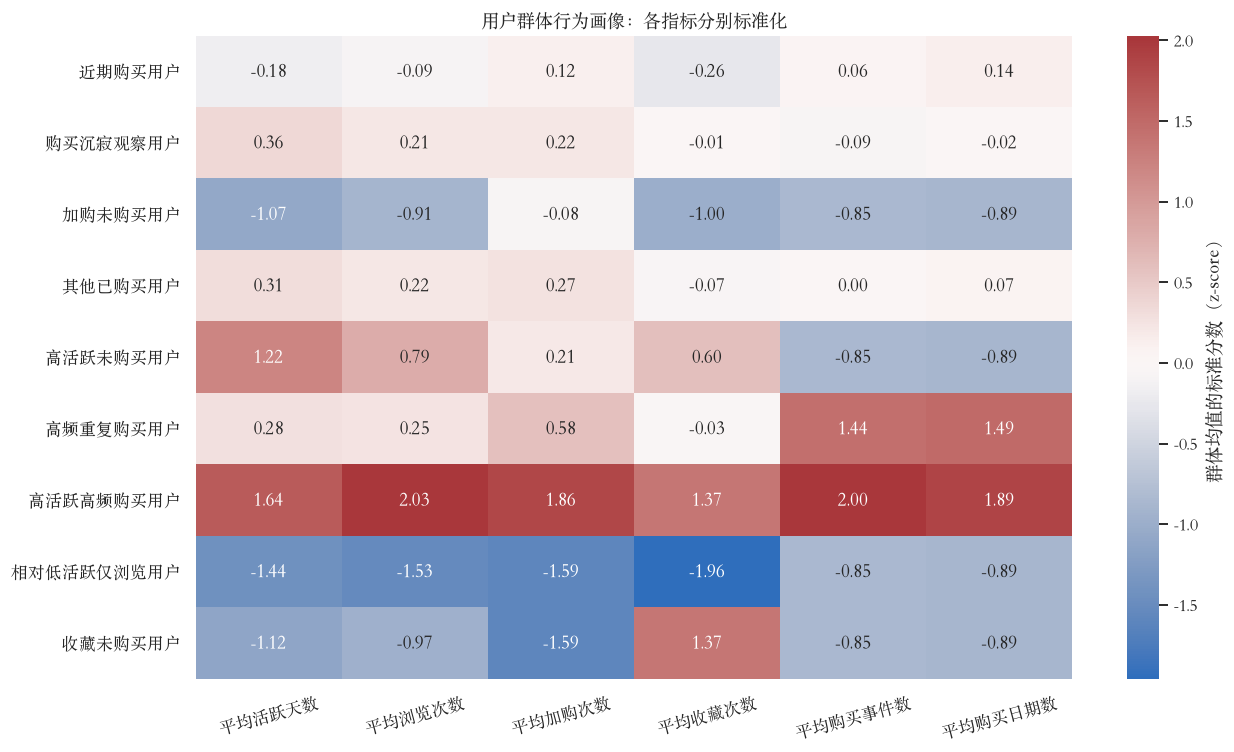

In [5]:
raw_profile = profile.loc[order, metrics]
std = raw_profile.std(ddof=0).replace(0, np.nan)
standardized = ((raw_profile - raw_profile.mean()) / std).fillna(0)
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(standardized.rename(index=segment_names, columns=metric_names),
            annot=True, fmt='.2f', cmap='vlag', center=0,
            cbar_kws={'label': '群体均值的标准分数（z-score）'}, ax=ax)
ax.set(title='用户群体行为画像：各指标分别标准化', xlabel='', ylabel='')
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
save_chart(fig, '02_segment_behavior_profile.png')

**图表解释：**每个指标单独按九个群体的均值计算 z-score，九个群体等权，不按人数加权。颜色仅比较群体特征，不是真实行为量或用户价值分数；原始均值见上表。分层使用活跃与购买指标，所以这些指标的差异部分来自规则本身，不能当成独立预测证据。

## 3. 重点人群：核心参与者与高活跃未购买者

以下按独立坐标比较两个重点群体和所有购买用户基线，不将天数、事件数、品类数混在一个数轴。购买品类广度只是行为广度，不代表金额贡献。

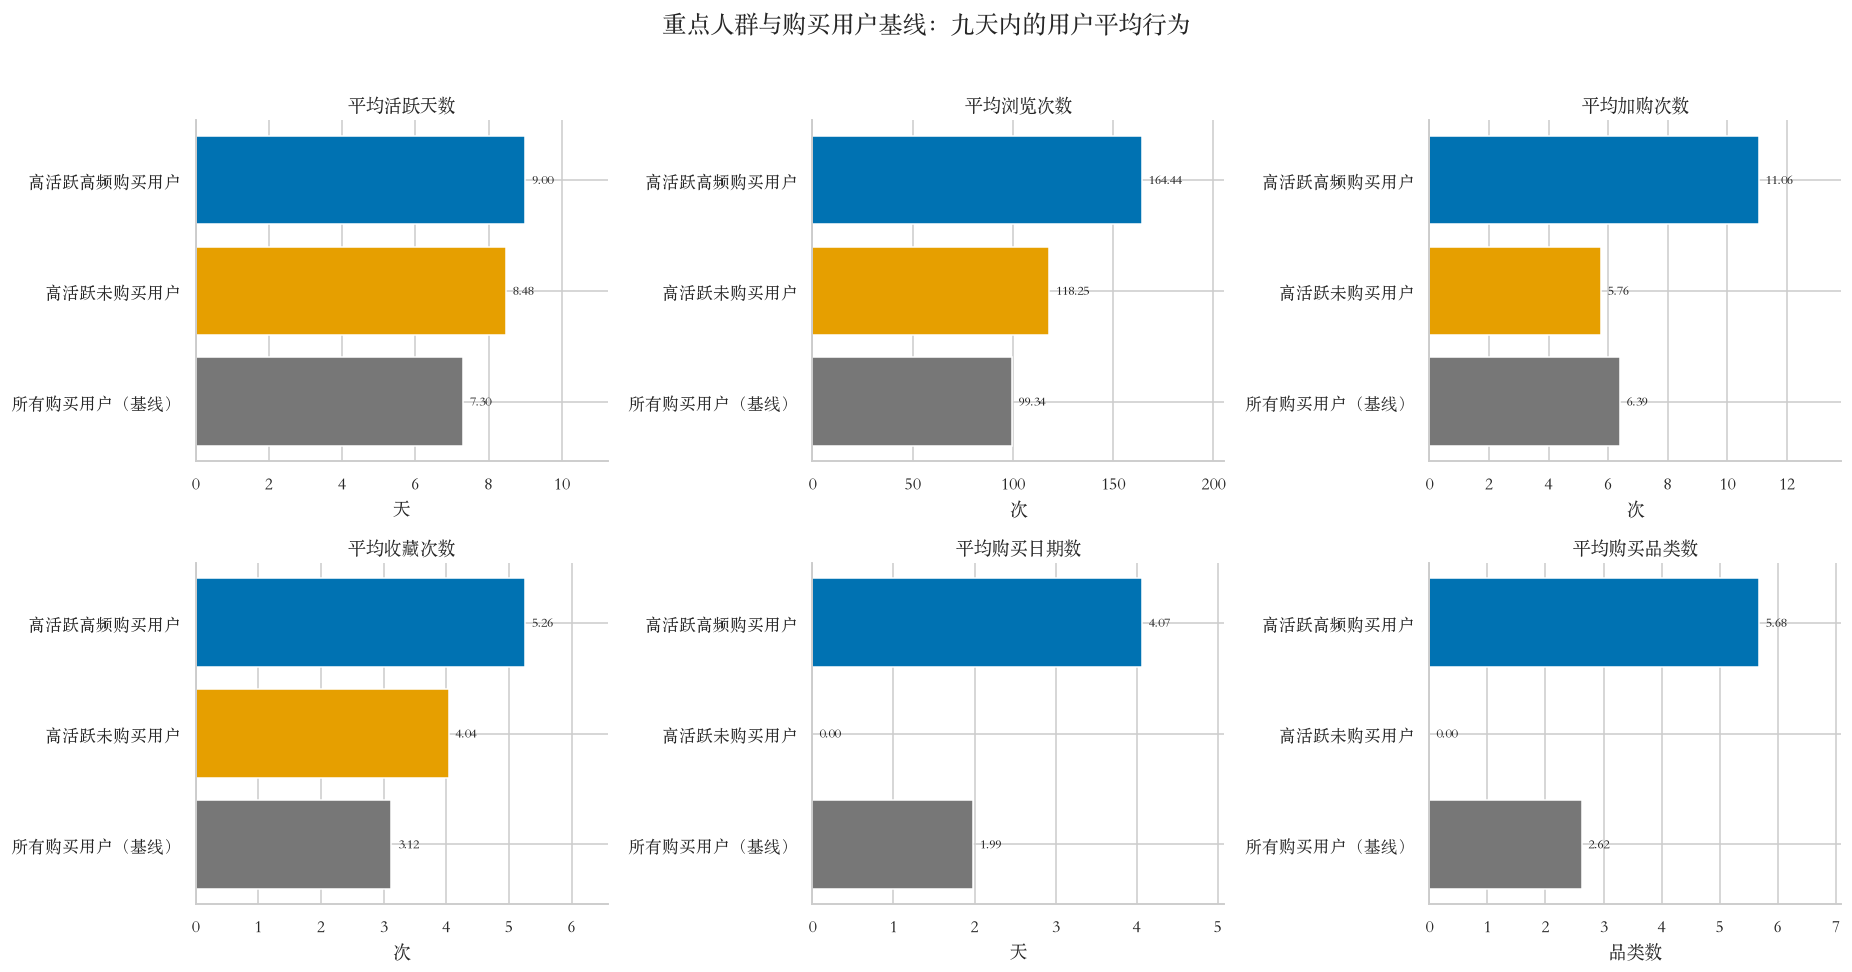

,active_days,pv_events,cart_events,fav_events,purchase_days,purchased_categories
高活跃高频购买用户,9.00,164.44,11.06,5.26,4.07,5.68
高活跃未购买用户,8.48,118.25,5.76,4.04,0.00,0.00
所有购买用户（基线）,7.30,99.34,6.39,3.12,1.99,2.62


**图表解释：**高活跃未购买群体中，**90.01%** 有加购或收藏。结合活跃、浏览和意向行为，可以描述较强参与与兴趣，但不能证明未来会购买。核心购买群体平均购买品类 **5.68** 个，体现窗口内的高参与购买，而非金额价值。

In [6]:
comparison_frames = {
    '高活跃高频购买用户': users.loc[users['segment_code'].eq('active_frequent_buyer')],
    '高活跃未购买用户': users.loc[users['segment_code'].eq('active_nonbuyer')],
    '所有购买用户（基线）': buyers,
}
focus_metrics = ['active_days', 'pv_events', 'cart_events', 'fav_events', 'purchase_days', 'purchased_categories']
focus_names = {**metric_names, 'purchased_categories': '平均购买品类数'}
comparison = pd.DataFrame({name: frame[focus_metrics].mean()
                           for name, frame in comparison_frames.items()}).T
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, metric in zip(axes.flat, focus_metrics):
    bars(ax, comparison.index, comparison[metric].to_numpy(),
         ['#0072B2', '#E69F00', '#777777'], focus_names[metric], '天' if metric in ['active_days', 'purchase_days'] else ('品类数' if metric == 'purchased_categories' else '次'))
fig.suptitle('重点人群与购买用户基线：九天内的用户平均行为', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_chart(fig, '06_focus_group_comparison.png')
active_nonbuyer = comparison_frames['高活跃未购买用户']
interest_share = (active_nonbuyer['cart_events'].gt(0) | active_nonbuyer['fav_events'].gt(0)).mean()*100
display(comparison.round(2))
display(Markdown(f'**图表解释：**高活跃未购买群体中，**{interest_share:.2f}%** 有加购或收藏。结合活跃、浏览和意向行为，可以描述较强参与与兴趣，但不能证明未来会购买。核心购买群体平均购买品类 **{comparison.loc["高活跃高频购买用户", "purchased_categories"]:.2f}** 个，体现窗口内的高参与购买，而非金额价值。'))

## 4. 加购未购买用户：意向强度与长尾

加购未购买是最终互斥群体，已排除先命中高活跃未购买的用户。因此它不等于全部有加购而未购买的用户。下面同时查看均值、中位数和分位数，避免只用均值概括长尾。

,count,mean,std,min,50%,75%,90%,95%,max
cart_events,129320.0,4.85,5.28,1.0,3.0,6.0,11.0,15.0,99.0
pv_events,129320.0,55.24,48.86,0.0,41.0,71.0,114.0,150.0,720.0
fav_events,129320.0,1.52,5.93,0.0,0.0,1.0,4.0,8.0,411.0
active_days,129320.0,5.65,1.14,1.0,6.0,7.0,7.0,7.0,7.0
distinct_categories,129320.0,16.84,10.85,1.0,14.0,21.0,30.0,37.0,214.0


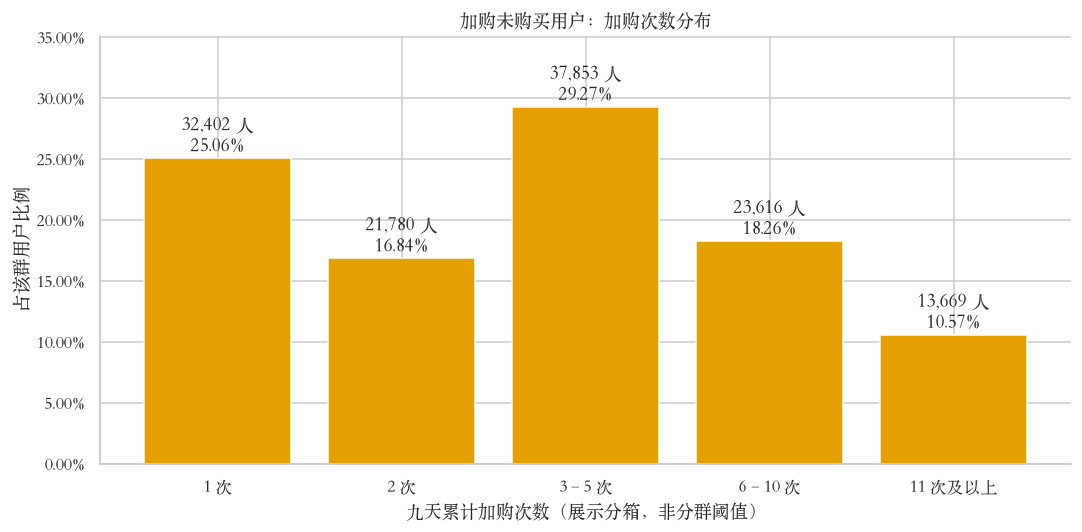

**图表解释：**该群全部有加购但未观测到 buy；其中 **25.47%** 同时有收藏。平均涉及 **16.84** 个品类。加购是意向信号，但不证明加购导致购买；展示分箱没有改变原分群规则。

In [7]:
cart_group = users.loc[users['segment_code'].eq('cart_nonbuyer')]
cart_metrics = ['cart_events', 'pv_events', 'fav_events', 'active_days', 'distinct_categories']
display(cart_group[cart_metrics].describe(percentiles=[.5, .75, .9, .95]).T.round(2))
cart_bins = pd.cut(cart_group['cart_events'], bins=[0, 1, 2, 5, 10, np.inf],
                   labels=['1 次', '2 次', '3–5 次', '6–10 次', '11 次及以上'])
cart_distribution = cart_bins.value_counts(sort=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cart_distribution.index.astype(str), cart_distribution / len(cart_group) * 100, color='#E69F00')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(100, decimals=2))
ax.set(title='加购未购买用户：加购次数分布', xlabel='九天累计加购次数（展示分箱，非分群阈值）', ylabel='占该群用户比例')
for i, count in enumerate(cart_distribution):
    ax.text(i, count/len(cart_group)*100 + .5, f'{count:,} 人\n{count/len(cart_group)*100:.2f}%', ha='center')
ax.set_ylim(0, (cart_distribution/len(cart_group)*100).max()*1.2)
fig.tight_layout()
save_chart(fig, '07_cart_nonbuyer_distribution.png')
display(Markdown(f'**图表解释：**该群全部有加购但未观测到 buy；其中 **{cart_group["fav_events"].gt(0).mean()*100:.2f}%** 同时有收藏。平均涉及 **{cart_group["distinct_categories"].mean():.2f}** 个品类。加购是意向信号，但不证明加购导致购买；展示分箱没有改变原分群规则。'))

## 5. 购买沉寂但仍然活跃

购买 Recency 与最近平台活跃不是同一指标。比较两种新近度，检验“未再次购买”是否同时意味着“离开平台”。

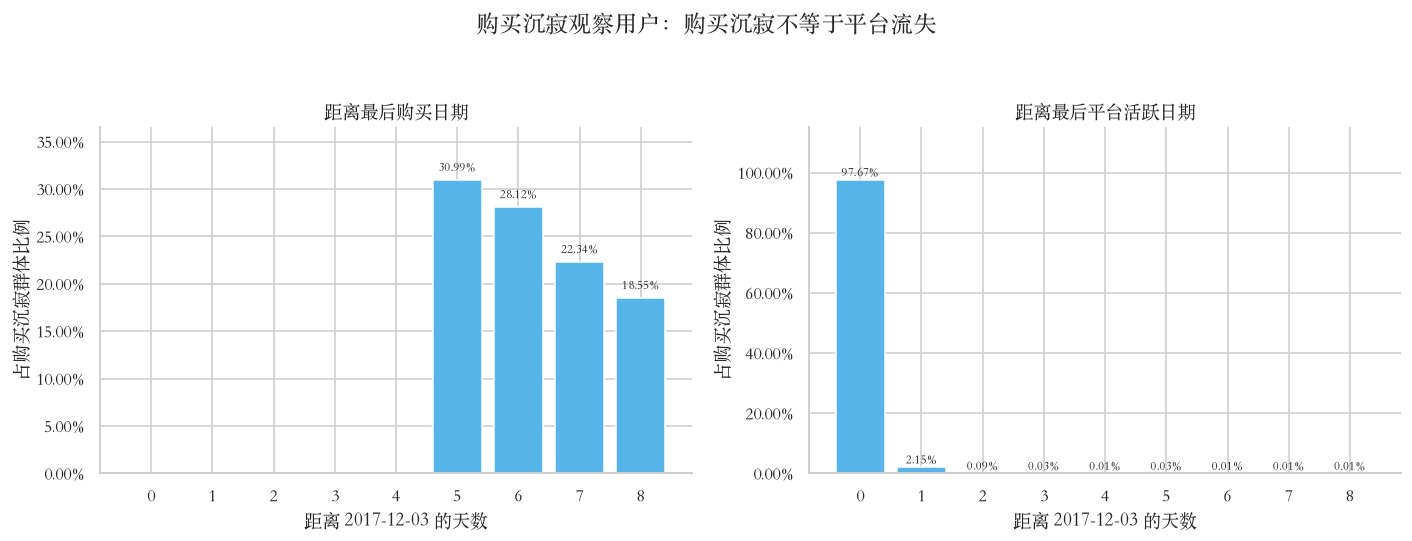

,count,mean,std,min,25%,50%,75%,max
recency_days,154066.0,6.284326,1.092829,5.0,5.0,6.0,7.0,8.0
days_since_last_active,154066.0,0.027819,0.220384,0.0,0.0,0.0,0.0,8.0
active_days,154066.0,7.420456,1.505967,1.0,6.0,8.0,9.0,9.0
pv_events,154066.0,96.835966,80.900532,0.0,39.0,74.0,130.0,810.0
cart_events,154066.0,5.812911,7.479771,0.0,1.0,3.0,8.0,134.0
fav_events,154066.0,3.073417,7.712755,0.0,0.0,0.0,3.0,335.0


**图表解释：**该群 **97.67%** 在 12/03 仍有行为，平均浏览 **96.84** 次、加购 **5.81** 次、收藏 **3.07** 次。这支持“多数仍活跃”的描述，不支持直接定义为流失用户。

In [8]:
cooling = users.loc[users['segment_code'].eq('purchase_cooling')]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, field, title in zip(axes, ['recency_days', 'days_since_last_active'],
                           ['距离最后购买日期', '距离最后平台活跃日期']):
    distribution = cooling[field].value_counts().reindex(range(9), fill_value=0)/len(cooling)*100
    ax.bar(distribution.index, distribution.values, color='#56B4E9')
    ax.set(title=title, xlabel='距离 2017-12-03 的天数', ylabel='占购买沉寂群体比例', xticks=range(9))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(100, decimals=2))
    for x, value in distribution.items():
        if value > 0: ax.text(x, value+.8, f'{value:.2f}%', ha='center', fontsize=8)
    ax.set_ylim(0, max(distribution.max()*1.18, 1))
fig.suptitle('购买沉寂观察用户：购买沉寂不等于平台流失', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.93))
save_chart(fig, '08_purchase_cooling_activity.png')
cooling_end_active_pct = cooling['days_since_last_active'].eq(0).mean()*100
display(cooling[['recency_days','days_since_last_active','active_days','pv_events','cart_events','fav_events']].describe().T.round(2))
display(Markdown(f'**图表解释：**该群 **{cooling_end_active_pct:.2f}%** 在 12/03 仍有行为，平均浏览 **{cooling["pv_events"].mean():.2f}** 次、加购 **{cooling["cart_events"].mean():.2f}** 次、收藏 **{cooling["fav_events"].mean():.2f}** 次。这支持“多数仍活跃”的描述，不支持直接定义为流失用户。'))

## 6. Recency × Frequency：购买用户的聚合行为结构

每个格子是一个 Recency（0–8 天）与不同购买日期数（1–9 天）的组合，不直接绘制 67 万个点。四区解释只是沿现有 SQL 的阈值观察行为结构，不生成新的 segment。

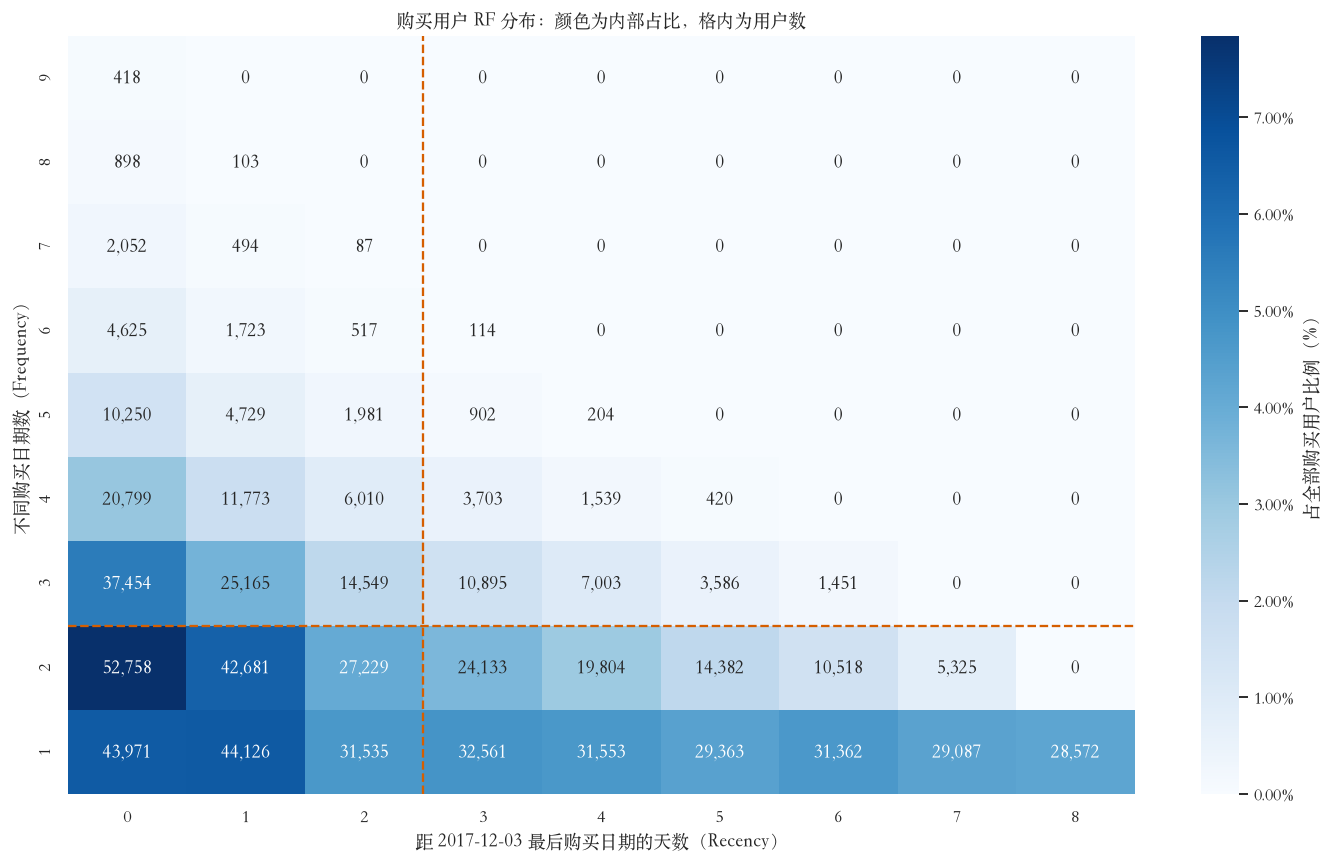

用户数
购买新近度结构 购买频次结构          
较久（>2天） 较低频（<3天）  256660
最近（≤2天） 较低频（<3天）  242300
        高频（≥3天）   143627
较久（>2天） 高频（≥3天）    29817

In [9]:
rf_counts = pd.crosstab(buyers['purchase_days'], buyers['recency_days']).reindex(
    index=range(1,10), columns=range(9), fill_value=0)
rf_share = rf_counts / len(buyers) * 100
annotations = rf_counts.map(lambda n: f'{n:,}')
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(rf_share, annot=annotations, fmt='', cmap='Blues',
            cbar_kws={'label':'占全部购买用户比例（%）'}, ax=ax)
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(ticker.PercentFormatter(100, decimals=2))
ax.invert_yaxis()
recent_threshold = int(thresholds.iloc[0]['buyer_recency_median'])
frequency_threshold = max(2, int(thresholds.iloc[0]['buyer_buy_days_q75']))
ax.axvline(recent_threshold+1, color='#D55E00', linestyle='--', linewidth=1.5)
ax.axhline(frequency_threshold-1, color='#D55E00', linestyle='--', linewidth=1.5)
ax.set(title='购买用户 RF 分布：颜色为内部占比，格内为用户数',
       xlabel='距 2017-12-03 最后购买日期的天数（Recency）',
       ylabel='不同购买日期数（Frequency）')
fig.tight_layout()
save_chart(fig, '03_rf_distribution.png')
rf_structure = pd.DataFrame({
    '购买新近度结构': np.where(buyers['recency_days']<=recent_threshold, '最近（≤2天）', '较久（>2天）'),
    '购买频次结构': np.where(buyers['purchase_days']>=frequency_threshold, '高频（≥3天）', '较低频（<3天）')})
display(rf_structure.value_counts().rename('用户数').to_frame())

**图表解释：**左上为最近且高频，左下为最近但较低频，右侧对应距最后购买更久的用户。每个颜色值的分母均为全部购买用户。较久（>2 天）不等于 SQL 的购买沉寂（>4 天）。部分格子是时间范围造成的结构性零：最后购买越早，能容纳的购买日期数越少，不能将空格解释为运营问题。

## 7. 未购买用户的潜在转化机会

内部占比以 **315,587 位未购买用户**为分母。优先级意味着高活跃未购买中可能也有加购或收藏，不能将它与两个意向群体当成独立行为集合。

,人数,未购买用户内部占比（%）,平均活跃天数,平均浏览次数,平均加购次数,平均收藏次数
segment_code,,,,,,
高活跃未购买用户,105478,33.42,8.48,118.25,5.76,4.04
加购未购买用户,129320,40.98,5.65,55.24,4.85,1.52
收藏未购买用户,31746,10.06,5.60,52.77,0.00,5.25
相对低活跃仅浏览用户,49043,15.54,5.20,32.04,0.00,0.00


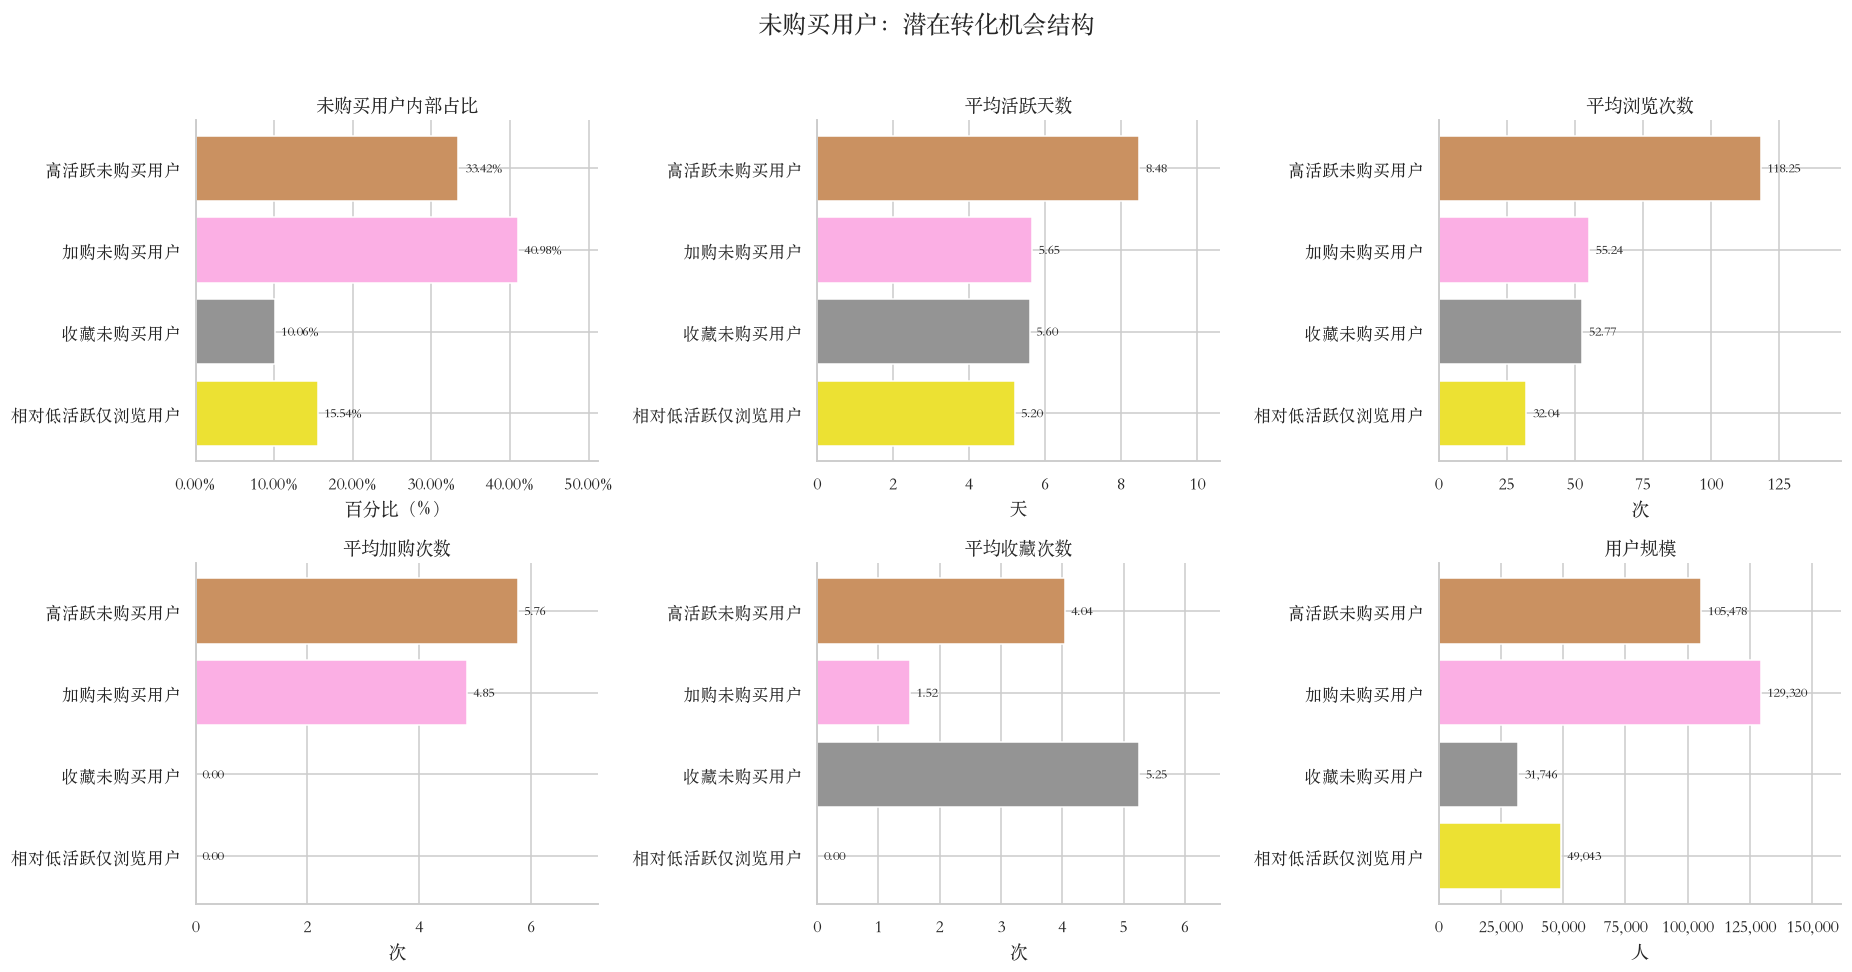

In [10]:
nonbuyer_codes = ['active_nonbuyer', 'cart_nonbuyer', 'favorite_nonbuyer', 'lower_activity_browser']
nonbuyer_profile = summary.loc[nonbuyer_codes].copy()
nonbuyer_profile['internal_share_pct'] = nonbuyer_profile['users']/len(nonbuyers)*100
display(nonbuyer_profile[['users','internal_share_pct','active_days','pv_events','cart_events','fav_events']]
        .rename(index=segment_names).rename(columns={**metric_names,'users':'人数','internal_share_pct':'未购买用户内部占比（%）'}).round(2))
fig, axes = plt.subplots(2,3,figsize=(17,9))
fields = ['internal_share_pct','active_days','pv_events','cart_events','fav_events','users']
titles = ['未购买用户内部占比','平均活跃天数','平均浏览次数','平均加购次数','平均收藏次数','用户规模']
for ax, field, title in zip(axes.flat, fields, titles):
    bars(ax, [segment_names[x] for x in nonbuyer_codes], nonbuyer_profile[field].to_numpy(),
         [segment_colors[x] for x in nonbuyer_codes], title,
         '百分比（%）' if field=='internal_share_pct' else ('人' if field=='users' else ('天' if field=='active_days' else '次')),
         percent=field=='internal_share_pct')
fig.suptitle('未购买用户：潜在转化机会结构', fontsize=16)
fig.tight_layout(rect=(0,0,1,.96))
save_chart(fig, '04_nonbuyer_opportunity.png')

**图表解释：**高活跃未购买群体的持续参与和加购未购买群体的直接意向信号值得优先调查；收藏可反映兴趣。机会优先级不能等同于未来购买概率，也未计算收入或触达收益。

## 8. 购买用户内部结构与“其他已购买”

内部占比以 672,404 位购买用户为分母。五类群体互斥；“近期购买”不包含已经优先命中高频规则的近期购买用户。

,users,internal_share_pct,active_days,buy_events,purchase_days,recency_days,purchased_categories
segment_code,,,,,,,
高活跃高频购买用户,63055,9.38,9.00,6.74,4.07,0.71,5.68
高频重复购买用户,104932,15.61,7.32,5.43,3.49,1.21,4.63
近期购买用户,242300,36.03,6.76,2.16,1.51,0.84,1.94
购买沉寂观察用户,154066,22.91,7.42,1.82,1.27,6.28,1.64
其他已购买用户,108051,16.07,7.36,2.02,1.41,3.48,1.82


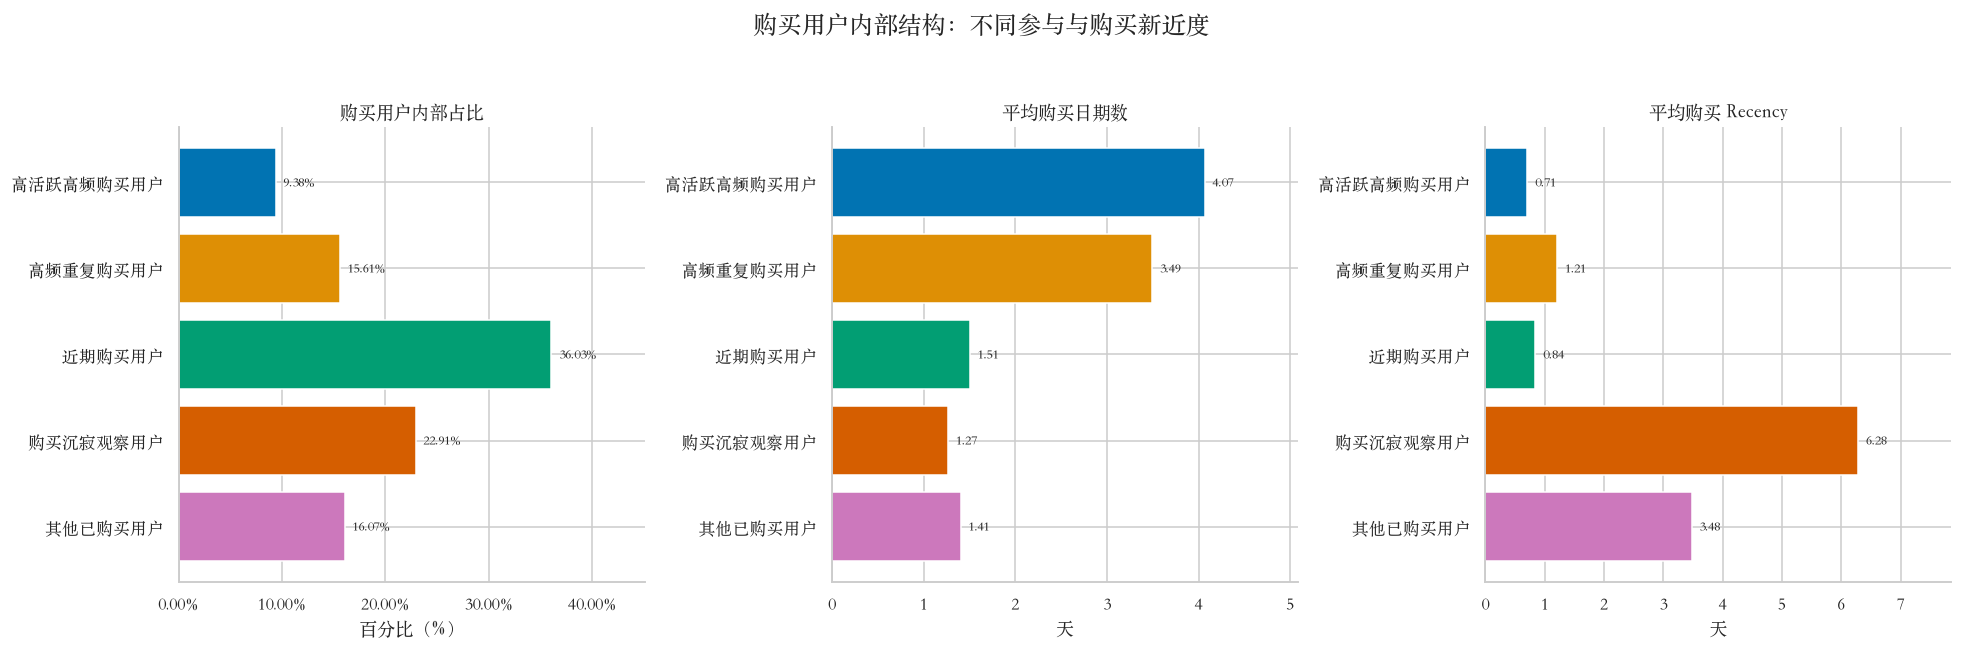

Recency 天数,3,4
购买日期数,,
1,32561,31553
2,24133,19804


**图表解释：**其他已购买共 **108,051** 人，占购买用户 **16.07%**；全部 Recency 为 **3–4 天**、购买日期数为 **1–2 天**。他们既不近期、也不超过沉寂阈值，频次低于高频阈值，因此进入兜底层。平均活跃 **7.36** 天，不能据此判断缺乏参与。可记录为后续研究的“中等新近度、较低购买日频次”结构，本章不改规则。

In [11]:
buyer_codes = ['active_frequent_buyer','frequent_buyer','recent_buyer','purchase_cooling','other_buyer']
buyer_profile = summary.loc[buyer_codes].copy()
buyer_profile['internal_share_pct'] = buyer_profile['users']/len(buyers)*100
display(buyer_profile[['users','internal_share_pct','active_days','buy_events','purchase_days','recency_days','purchased_categories']]
        .rename(index=segment_names).round(2))
fig, axes = plt.subplots(1,3,figsize=(18,6))
for ax, field, title in zip(axes,['internal_share_pct','purchase_days','recency_days'],
                           ['购买用户内部占比','平均购买日期数','平均购买 Recency']):
    bars(ax,[segment_names[x] for x in buyer_codes],buyer_profile[field].to_numpy(),
         [segment_colors[x] for x in buyer_codes],title,'百分比（%）' if field=='internal_share_pct' else '天',
         percent=field=='internal_share_pct')
fig.suptitle('购买用户内部结构：不同参与与购买新近度',fontsize=16)
fig.tight_layout(rect=(0,0,1,.94))
save_chart(fig,'05_buyer_segment_profile.png')
other = users.loc[users['segment_code'].eq('other_buyer')]
assert other['recency_days'].between(3,4).all() and other['purchase_days'].between(1,2).all()
display(pd.crosstab(other['purchase_days'],other['recency_days']).rename_axis(index='购买日期数',columns='Recency 天数'))
display(Markdown(f'**图表解释：**其他已购买共 **{len(other):,}** 人，占购买用户 **{len(other)/len(buyers)*100:.2f}%**；全部 Recency 为 **3–4 天**、购买日期数为 **1–2 天**。他们既不近期、也不超过沉寂阈值，频次低于高频阈值，因此进入兜底层。平均活跃 **{other["active_days"].mean():.2f}** 天，不能据此判断缺乏参与。可记录为后续研究的“中等新近度、较低购买日频次”结构，本章不改规则。'))

## 9. 核心业务发现

以下数字由已校验的用户明细计算。“事实”与“解释/方向”分开，适合选入 README。

In [12]:
core = users.loc[users['segment_code'].eq('active_frequent_buyer')]
repeat_users = int(buyers['purchase_days'].ge(2).sum())
findings = [
 f'**核心参与购买群体。事实：**{len(core):,} 人（全体 {len(core)/len(users)*100:.2f}%），平均活跃 {core.active_days.mean():.2f} 天、购买事件 {core.buy_events.mean():.2f} 次、购买日期 {core.purchase_days.mean():.2f} 天、购买品类 {core.purchased_categories.mean():.2f} 个。**解释：**行为参与强，不能推断金额最高。',
 f'**窗口内跨日重复购买。事实：**{repeat_users:,} 人，占购买用户 {repeat_users/len(buyers)*100:.2f}%。**解释：**存在重复购买日期，不是订单复购率或长期复购率。',
 f'**高活跃未购买。事实：**{len(active_nonbuyer):,} 人，平均活跃 {active_nonbuyer.active_days.mean():.2f} 天、浏览 {active_nonbuyer.pv_events.mean():.2f} 次；{interest_share:.2f}% 有加购或收藏。**解释：**参与与兴趣尚未对应窗口内购买，值得调查转化障碍。',
 f'**加购意向未兑现。事实：**最终加购未购买群体 {len(cart_group):,} 人，占未购买用户 {len(cart_group)/len(nonbuyers)*100:.2f}%，平均加购 {cart_group.cart_events.mean():.2f} 次。**解释：**可探索购物车召回机会，不能保证购买或推断失败原因。',
 f'**购买沉寂不等于平台流失。事实：**{len(cooling):,} 人，平均购买 Recency {cooling.recency_days.mean():.2f} 天，但 {cooling_end_active_pct:.2f}% 在 12/03 仍活跃。**解释：**再购买刺激比直接套用流失标签更值得验证。',
 f'**兜底群体具有清晰结构。事实：**其他已购买 {len(other):,} 人，全部 Recency 3–4 天且购买日期 1–2 天，平均活跃 {other.active_days.mean():.2f} 天。**解释：**可单独研究购买节奏，无需本章修改分层。',
 f'**相对低活跃也可能多日参与。事实：**相对低活跃仅浏览用户平均活跃 {profile.loc["lower_activity_browser","active_days"]:.2f} 天。**解释：**分位标签是相对状态，不能当成绝对不活跃或低收入价值。'
]
display(Markdown('\n\n'.join(f'{i}. {item}' for i,item in enumerate(findings,1))))

1. **核心参与购买群体。事实：**63,055 人（全体 6.38%），平均活跃 9.00 天、购买事件 6.74 次、购买日期 4.07 天、购买品类 5.68 个。**解释：**行为参与强，不能推断金额最高。

2. **窗口内跨日重复购买。事实：**370,274 人，占购买用户 55.07%。**解释：**存在重复购买日期，不是订单复购率或长期复购率。

3. **高活跃未购买。事实：**105,478 人，平均活跃 8.48 天、浏览 118.25 次；90.01% 有加购或收藏。**解释：**参与与兴趣尚未对应窗口内购买，值得调查转化障碍。

4. **加购意向未兑现。事实：**最终加购未购买群体 129,320 人，占未购买用户 40.98%，平均加购 4.85 次。**解释：**可探索购物车召回机会，不能保证购买或推断失败原因。

5. **购买沉寂不等于平台流失。事实：**154,066 人，平均购买 Recency 6.28 天，但 97.67% 在 12/03 仍活跃。**解释：**再购买刺激比直接套用流失标签更值得验证。

6. **兜底群体具有清晰结构。事实：**其他已购买 108,051 人，全部 Recency 3–4 天且购买日期 1–2 天，平均活跃 7.36 天。**解释：**可单独研究购买节奏，无需本章修改分层。

7. **相对低活跃也可能多日参与。事实：**相对低活跃仅浏览用户平均活跃 5.20 天。**解释：**分位标签是相对状态，不能当成绝对不活跃或低收入价值。

## 10. 建议测试的用户运营方向

| 人群 | 可考虑的动作 | 建议验证指标 |
|---|---|---|
| 高活跃高频购买 | 会员权益、个性化推荐、新品推荐 | 增量购买用户、不同购买日期数、触达成本 |
| 高频重复购买 | 关联推荐、组合购、忠诚度运营 | 增量跨日购买、购买品类广度 |
| 近期购买 / 其他已购买 | 购买后推荐、交叉销售、购买节奏研究 | 后续购买用户与购买日期数 |
| 高活跃未购买 | 调查浏览—购买障碍，商品推荐与优惠测试 | 用户级购买转化、优惠成本 |
| 加购未购买 | 购物车召回；有实时商品数据时测试价格变化/库存提醒 | 增量购买用户、触达成本、退订反馈 |
| 收藏未购买 | 兴趣内容与收藏商品推荐 | 增量参与及购买用户 |
| 购买沉寂观察 | 针对仍活跃者测试再购买刺激 | 后续购买用户、增量收益（需补金额数据） |
| 相对低活跃仅浏览 | 低成本触达、兴趣探索，避免高成本营销 | 增量活跃、触达成本及负面反馈 |

这些是待验证方向，数据没有证明动作有效。若条件允许，随机分组并统一后续观察窗口、报告增量效果与成本。

## 11. 后续优化记录与分析限制

- 保留现有规则；“其他已购买”可增加更直观的说明或进一步研究，但改名/改规则需单独验证。
- 购买沉寂群体多数仍活跃，建议下一阶段联合最近活跃与品类购买周期，而非直接升级为流失标签。
- 高活跃未购买优先于加购/收藏，适合进一步保留交叉行为标签；最终分层依旧互斥。
- 分位阈值有整数并列；九天数据整体活跃很高，应调查数据抽样方式与覆盖人群，再评估阈值稳健性。
- 规则定义了部分画像差异，不能据此宣称分层具有预测能力。均值可能受长尾影响，重点群体同时展示分位数。
- 未知窗前历史，窗口后购买不可见；晚进入用户机会更少，首次观测日不是注册日。需要更长时间数据验证长期状态。
- 无价格、金额、order_id、真实库存或触达记录；不能衡量收入贡献、订单数、长期购买周期或验证优惠效果。
- 行为覆盖不代表同商品有序路径，不假定固定浏览—收藏—加购—购买流程。RF 图只描述行为结构，不重定义分群。

图表导出至 `reports/figures/`；没有修改原始表或执行 git commit。

In [13]:
saved_figures = sorted(figure_dir.glob('*.png'))
print('本章导出的图表：')
for filename in ['01_segment_distribution.png','02_segment_behavior_profile.png',
                 '03_rf_distribution.png','04_nonbuyer_opportunity.png','05_buyer_segment_profile.png',
                 '06_focus_group_comparison.png','07_cart_nonbuyer_distribution.png','08_purchase_cooling_activity.png']:
    path = figure_dir / filename
    assert path.exists() and path.stat().st_size > 0
    print(filename)
print('分析完成：用户与分群校验通过，图表已保存。')

本章导出的图表：
01_segment_distribution.png
02_segment_behavior_profile.png
03_rf_distribution.png
04_nonbuyer_opportunity.png
05_buyer_segment_profile.png
06_focus_group_comparison.png
07_cart_nonbuyer_distribution.png
08_purchase_cooling_activity.png
分析完成：用户与分群校验通过，图表已保存。
